In [1]:
!pip install -q transformers timm peft accelerate

In [2]:
!pip install -q transformers timm pytesseract
!apt-get -qq install -y tesseract-ocr

In [3]:
import shutil
shutil.rmtree("/kaggle/working/cardiovlm_ckpt", ignore_errors=True)

Using device: cuda
Paired: 2500 patients | rhythm-only (no beat file found): 5 | beat-only (no rhythm file found): 3 | unmatched filenames: 0
Loaded cached metadata: 2500 paired records


Metadata path: /kaggle/input/datasets/afrinakterafrinakter/ex-31csv/ecg_metadata_paired_5k (1).csv
Shape: (2500, 35)
hr      1
pr     83
qrs     1
qt      1
qtc     1
dtype: int64


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Split: train=1750 val=375 test=375
Numeric normalization statistics calculated from train_df only.


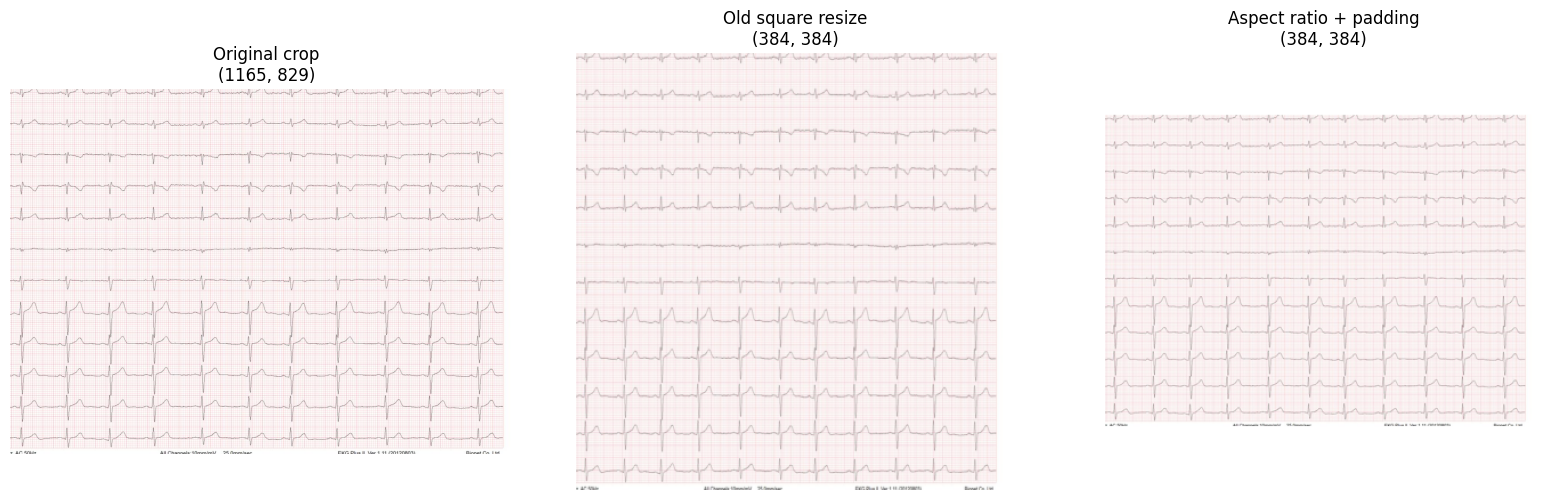

Original size: (1165, 829)
Old resized size: (384, 384)
New padded canvas size: (384, 384)
Original content aspect ratio: 1.4053
New content aspect ratio: 1.4066
New output canvas ratio: 1.0
Per-condition pos_weight (higher = rarer, gets more gradient signal):
  Normal Sinus Rhythm          weight=  1.00  train_support=1368
  Normal Axis                  weight=  1.00  train_support=1608
  Normal ECG                   weight=  1.00  train_support=937
  ICRBBB                       weight=  8.00  train_support=174
  Atrial Fibrillation          weight=  8.00  train_support=11
  Sinus Bradycardia            weight=  8.00  train_support=72
  Sinus Tachycardia            weight=  5.63  train_support=264
  Left Axis Deviation          weight=  8.00  train_support=72
  Right Axis Deviation         weight=  8.00  train_support=30
  Inferior MI                  weight=  8.00  train_support=43
  Anteroseptal MI              weight=  8.00  train_support=13
  MI                           weight= 

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Epoch 1/15 | loss=1.3888 cls=0.5826 report=5.3744 | exact_match=0.589 per_label_acc=0.953 macro_f1=0.230
  (epoch 1 < min_decoder_epochs=8 — decoder warmup, not yet eligible for checkpoint selection)
Epoch 2/15 | loss=0.6099 cls=0.4869 report=0.8198 | exact_match=0.512 per_label_acc=0.945 macro_f1=0.256
  (epoch 2 < min_decoder_epochs=8 — decoder warmup, not yet eligible for checkpoint selection)
Epoch 3/15 | loss=0.5034 cls=0.4505 report=0.3523 | exact_match=0.403 per_label_acc=0.938 macro_f1=0.267
  (epoch 3 < min_decoder_epochs=8 — decoder warmup, not yet eligible for checkpoint selection)
Epoch 4/15 | loss=0.4368 cls=0.4032 report=0.2243 | exact_match=0.240 per_label_acc=0.914 macro_f1=0.296
  (epoch 4 < min_decoder_epochs=8 — decoder warmup, not yet eligible for checkpoint selection)
Epoch 5/15 | loss=0.3992 cls=0.3714 report=0.1853 | exact_match=0.336 per_label_acc=0.928 macro_f1=0.326
  (epoch 5 < min_decoder_epochs=8 — decoder warmup, not yet eligible for checkpoint selection)


In [4]:
"""
CardioVLM — Paired Rhythm + Beat Report Pipeline
=====================================================================================
Your dataset has TWO files per patient (confirmed from uploaded samples, ID "09"):
  - "<id>_12 channel report.jpg"  -> full 12-lead rhythm strip + diagnosis text
  - "<id>_Beat report.jpg"        -> per-lead numeric table + a REAL representative
                                     beat waveform montage (12 small traces, grid layout)

This replaces the earlier "fake beat" version (which cropped a random lead-II
strip out of the rhythm image as a stand-in). Now:
  1. Files are PAIRED by patient ID, normalizing filename inconsistencies
     (e.g. "1,032" / "1_015" / "09" all become plain digit strings).
  2. `ecg_image`  = the 12-lead grid, cropped from the rhythm report (unchanged).
  3. `beat_image` = the actual 12-panel beat waveform montage, cropped from the
     beat report (the real modality, not a proxy).
  4. Numeric fields (HR/PR/QRS/QT/QTc/axes) are OCR'd from the beat report's
     left-column header FIRST (tested to be more reliable, including axes),
     falling back to the rhythm report's header if any field is missing there.
  5. Diagnosis text/labels still come from the rhythm report's "Analysis
     Result" column — it's the only file that has it.

Install once at top of a Kaggle notebook cell:
    !pip install -q transformers timm pytesseract
    !apt-get -qq install -y tesseract-ocr
"""

import os
import re
import glob
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageOps
import torchvision.transforms as T

try:
    import pytesseract
except ImportError:
    os.system("pip install -q pytesseract")
    import pytesseract

try:
    import timm
except ImportError:
    os.system("pip install -q timm")
    import timm

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from transformers.modeling_outputs import BaseModelOutput
from sklearn.metrics import accuracy_score, f1_score

# ---------------------------------------------------------------------------
# 0. CONFIG
# ---------------------------------------------------------------------------

class CFG:
    seed = 42
    device = "cuda" if torch.cuda.is_available() else "cpu"

    raw_image_dir = "/kaggle/input/datasets/afrinakterafrinakter/1dataset/1(dataset)"  # <-- CHANGE IF NEEDED
    metadata_csv = "/kaggle/input/datasets/afrinakterafrinakter/ex-31csv/ecg_metadata_paired_5k (1).csv"
    img_size = 384    # was 224 — RBBB/ICRBBB (F1=0.000-0.13 despite 90-99 training
                        # examples, consistent across two runs) depend on a subtle
                        # V1 notch pattern that likely gets destroyed when a
                        # 1280x830 grid is squeezed down to 224x224. 384 preserves
                        # more of that fine detail at a manageable compute cost.
    num_numeric_features = 6      # hr, pr, qrs, qt, qtc, axes_missing
    fusion_dim = 256
    fusion_heads = 4
    transformer_layers = 2

    decoder_name = "google/flan-t5-small"
    max_report_len = 64

    batch_size = 8
    epochs = 15
    # Checkpoint selection is driven by classification macro_f1 alone (see
    # below) — but the decoder converges more slowly than the classifier, and
    # how much slower isn't fixed: it depends on dataset size/composition. On
    # the smaller dataset both converged around the same timescale (15 epochs,
    # never early-stopped) and this was never a problem. On the larger dataset
    # classification saturated fast (best macro_f1 at epoch 3, early-stopped at
    # epoch 7) while report_loss was still 0.36 at epoch 3 vs 0.13 by epoch 8 —
    # freezing "best" at epoch 3 locked in an undertrained decoder, and
    # "Normal Axis" dropped out of generated reports again as a direct result,
    # even though the decoder LR fix itself was still working correctly.
    # This floor stops a checkpoint from being frozen as "best" before the
    # decoder has had a baseline number of steps, regardless of how fast
    # classification alone converges.
    min_decoder_epochs = 8
    lr = 2e-4
    decoder_lr = 1e-4
    cls_loss_weight = 1.0
    report_loss_weight = 0.15   # report_loss runs ~30-50x larger than cls_loss;
                                 # equal weighting let it dominate gradients and
                                 # destabilize the classifier (see exact_match
                                 # dropping to 0.159 at epoch 4 in the unweighted run)

    # report_loss_weight above exists to protect the SHARED backbone (image/beat/
    # numeric encoders, fusion, transformer) from being swamped by report_loss —
    # but decoder-only parameters get ZERO gradient from cls_loss, so scaling
    # their gradient by report_loss_weight too doesn't balance anything for them,
    # it just shrinks their effective LR to decoder_lr * report_loss_weight =
    # 1e-4 * 0.15 = 1.5e-5. That's a very small update rate for a pretrained LM
    # that needs to learn new cross-attention behavior in ~500 total training
    # steps, and is the most likely reason the decoder converged to a near-
    # input-independent output regardless of two prior (disproven) fixes.
    # Compensating here restores the decoder's effective LR back to decoder_lr.
    effective_decoder_lr = decoder_lr / report_loss_weight

    out_dir = "/kaggle/working/cardiovlm_ckpt"

    # 3-way split: train (fit the model) / val (checkpoint selection + threshold
    # tuning — used repeatedly during development) / test (touched EXACTLY ONCE,
    # at the very end, for the numbers that go in the paper). Previously this
    # was a single 80/20 split doing all three jobs at once — that's data
    # leakage: the reported macro_f1/F1 were optimistic because the same val
    # data influenced both which checkpoint got picked AND which threshold got
    # picked AND was what got reported as "performance."
    train_frac = 0.70
    val_frac = 0.15
    # test_frac is whatever remains (~0.15)

    # k-fold calibration (separate from the main train/val run above, which
    # still produces the deployed checkpoint). Purpose: get reliable per-label
    # thresholds/F1 for rare conditions. A single 80/20 split gives ICRBBB-tier
    # classes only ~4-9 held-out examples (e.g. Anteroseptal MI, ST abnormality,
    # RVH) — a tuned threshold from that few points is fitting noise, not a real
    # decision boundary (this is why the last run's tuned Inferior MI threshold
    # of 0.80 still let a 0.801 false positive through on a normal patient).
    # 5-fold CV pools every patient's out-of-fold prediction once, giving each
    # rare class ~its full dataset count worth of held-out evaluations instead
    # of a random 20% slice of it.
    cv_folds = 5
    cv_epochs = 8            # lighter than the main run's 15 — these folds only
                               # need to be good enough for threshold/F1 estimates,
                               # not to produce a deployed model
    min_pooled_support_for_tuning = 15   # below this, a "tuned" threshold is
                                            # noise fitting; fall back to 0.5 and
                                            # flag it as a data limitation instead


NUMERIC_COLS = ["hr", "pr", "qrs", "qt", "qtc", "axes_missing"]

CONDITION_VOCAB = [
    "Normal Sinus Rhythm", "Normal Axis", "Normal ECG",
    "ICRBBB",   # LBBB dropped: only 2 examples in the whole dataset (last run's
                # pos_weight printout) — can't be trained or evaluated
    "Atrial Fibrillation",   # "AFib" alias dropped: 0 occurrences — the OCR'd
                              # text always spells this out, never abbreviates
    "Sinus Bradycardia", "Sinus Tachycardia",
    "Left Axis Deviation", "Right Axis Deviation",
    # "First Degree AV Block" and generic "Myocardial Infarction" (the literal
    # phrase) dropped: 0 train_support in the last run — they never appear
    # verbatim in the OCR'd diagnosis text, so they were pure dead columns.
    "Inferior MI", "Anteroseptal MI",   # kept — 34 and 5 train examples, usable
    "MI",   # generic catch-all; also now absorbs "Lateral MI"/"Posterior MI"
            # text (1 example each — too few to be their own trainable class,
            # but the word "MI" still appears in that text so they still count
            # toward this bucket, per the cell7/8 fix's original reasoning)
    "ST abnormality", "Markedly Abnormal ECG",
    "LVH", "RVH", "PVC",
    "Low Voltage", "PAC",
]


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(CFG.seed)
os.makedirs(CFG.out_dir, exist_ok=True)


# ---------------------------------------------------------------------------
# 1. FILE PAIRING
#    Handles the ID-format inconsistency seen across your files
#    ("1,032_12_channel_report.jpg", "1_015_12_channel_report.jpg",
#     "09_12 channel report.jpg", "09_Beat report.jpg", ...)
# ---------------------------------------------------------------------------

RHYTHM_SUFFIX_RE = re.compile(r"^(.*?)[_,]?12[_ ]?channel[_ ]?report\.(jpg|jpeg|png)$", re.IGNORECASE)
BEAT_SUFFIX_RE = re.compile(r"^(.*?)[_,]?beat[_ ]?report\.(jpg|jpeg|png)$", re.IGNORECASE)


def normalize_patient_id(raw):
    """Strips separators (',', '_', ' ') so '1,032' / '1_015' / '09' become
    comparable digit strings regardless of formatting quirks."""
    digits = re.sub(r"\D", "", raw)
    digits = digits.lstrip("0") or "0"
    return digits


def find_patient_pairs(image_dir):
    files = sorted(glob.glob(os.path.join(image_dir, "*.jpg")) +
                    glob.glob(os.path.join(image_dir, "*.jpeg")) +
                    glob.glob(os.path.join(image_dir, "*.png")))
    if not files:
        raise FileNotFoundError(f"No image files found in {image_dir}")

    rhythm_map, beat_map = {}, {}
    unmatched = []
    for path in files:
        base = os.path.basename(path)
        m_rhythm = RHYTHM_SUFFIX_RE.match(base)
        m_beat = BEAT_SUFFIX_RE.match(base)
        if m_rhythm:
            pid = normalize_patient_id(m_rhythm.group(1))
            rhythm_map[pid] = path
        elif m_beat:
            pid = normalize_patient_id(m_beat.group(1))
            beat_map[pid] = path
        else:
            unmatched.append(base)

    paired_ids = sorted(set(rhythm_map) & set(beat_map))
    pairs = [{"patient_id": pid, "rhythm_path": rhythm_map[pid], "beat_path": beat_map[pid]}
              for pid in paired_ids]

    only_rhythm = set(rhythm_map) - set(beat_map)
    only_beat = set(beat_map) - set(rhythm_map)
    print(f"Paired: {len(pairs)} patients | "
          f"rhythm-only (no beat file found): {len(only_rhythm)} | "
          f"beat-only (no rhythm file found): {len(only_beat)} | "
          f"unmatched filenames: {len(unmatched)}")
    if unmatched:
        print("First few unmatched filenames (check naming pattern):", unmatched[:5])

    return pairs


# ---------------------------------------------------------------------------
# 2. IMAGE CROPPING (verified against your uploaded 1280x960 samples)
# ---------------------------------------------------------------------------

def crop_rhythm_regions(image_path):
    im = Image.open(image_path).convert("RGB")
    w, h = im.size
    header = im.crop((0, 0, w, int(h * 0.12)))
    # x-start moved to 9% (measured precisely: label glyphs span pixel columns
    # 55-95 out of 1280 width = 4.3%-7.4%, NOT 0-40px as originally assumed —
    # the earlier 4% cut sliced through the START of the labels instead of
    # past them, which is why they were still fully visible in the overlay).
    # 9% clears the measured range with margin. Verified visually before use.
    grid = im.crop((int(w * 0.09), int(h * 0.12), w, int(h * 0.984)))
    return {"header": header, "grid": grid}


def crop_beat_regions(image_path):
    im = Image.open(image_path).convert("RGB")
    w, h = im.size
    # left-column header block: ID/Name/Age/HR/PR/QRS/QT-QTc/axes — verified clean OCR
    left_header = im.crop((0, int(h * 0.026), int(w * 0.2), int(h * 0.25)))
    # 12-panel beat waveform montage, below the numeric table
    grid = im.crop((0, int(h * 0.396), w, int(h * 0.984)))
    return {"left_header": left_header, "grid": grid}


# ---------------------------------------------------------------------------
# 3. OCR PARSING
#    Same field labels appear on BOTH rhythm and beat headers, so one parser
#    works for either crop. Beat-report header is tried first (cleaner OCR,
#    verified on your samples), rhythm header fills in anything missing.
# ---------------------------------------------------------------------------

def _prep_for_ocr(img, scale=3):
    img = img.convert("L")
    img = img.resize((img.width * scale, img.height * scale), Image.LANCZOS)
    return ImageOps.autocontrast(img)


def parse_numeric_block(img):
    text = pytesseract.image_to_string(_prep_for_ocr(img), config="--psm 6")

    def find_num(pattern, default=np.nan):
        m = re.search(pattern, text, re.IGNORECASE)
        return float(m.group(1)) if m else default

    hr = find_num(r"Heart\s*Rate\s*:?\s*[:\.]?\s*(\d{2,3})")
    pr = find_num(r"PR\s*int\.?\s*:?\s*(\d{2,3})")
    qrs = find_num(r"QRS\s*dur\.?\s*:?\s*(\d{2,3})")
    qt_qtc = re.search(r"(\d{2,3})\s*/\s*(\d{2,3})", text)
    qt = float(qt_qtc.group(1)) if qt_qtc else np.nan
    qtc = float(qt_qtc.group(2)) if qt_qtc else np.nan
    axes_match = re.search(r"(-?\d{1,3})\s*[-–]\s*(-?\d{1,3})\s*[-–]\s*(-?\d{1,3})", text)
    axes_missing = 0.0 if axes_match else 1.0

    return {"hr": hr, "pr": pr, "qrs": qrs, "qt": qt, "qtc": qtc, "axes_missing": axes_missing}


def parse_diagnosis(rhythm_header_img, w):
    result_crop = rhythm_header_img.crop((int(w * 0.375), 0, int(w * 0.72), rhythm_header_img.height))
    text = pytesseract.image_to_string(_prep_for_ocr(result_crop), config="--psm 6")

    labels = np.zeros(len(CONDITION_VOCAB), dtype=np.float32)
    text_lower = text.lower()
    for i, cond in enumerate(CONDITION_VOCAB):
        # word-boundary match, not plain substring — "mi" as a plain substring
        # was matching inside "Minimally" (Minimally Abnormal appears in most
        # records), causing widespread false-positive MI labels
        if re.search(r"\b" + re.escape(cond.lower()) + r"\b", text_lower):
            labels[i] = 1.0
    return labels, text.strip().replace("\n", " ")


def parse_patient_record(rhythm_path, beat_path):
    rhythm_regions = crop_rhythm_regions(rhythm_path)
    beat_regions = crop_beat_regions(beat_path)

    primary = parse_numeric_block(beat_regions["left_header"])      # tried first
    fallback = parse_numeric_block(rhythm_regions["header"])         # fills gaps

    merged = {}
    for k in ["hr", "pr", "qrs", "qt", "qtc"]:
        merged[k] = primary[k] if not np.isnan(primary[k]) else fallback[k]
    merged["axes_missing"] = min(primary["axes_missing"], fallback["axes_missing"])

    labels, raw_text = parse_diagnosis(rhythm_regions["header"], rhythm_regions["header"].width)
    merged["labels"] = labels
    merged["raw_result_text"] = raw_text
    return merged


# ---------------------------------------------------------------------------
# 4. BUILD METADATA CSV (run ONCE)
# ---------------------------------------------------------------------------

def build_metadata_csv(image_dir, out_csv):
    pairs = find_patient_pairs(image_dir)

    rows = []
    for pair in pairs:
        parsed = parse_patient_record(pair["rhythm_path"], pair["beat_path"])
        row = {
            "patient_id": pair["patient_id"],
            "rhythm_path": pair["rhythm_path"],
            "beat_path": pair["beat_path"],
            **{k: parsed[k] for k in NUMERIC_COLS},
            "raw_result_text": parsed["raw_result_text"],
        }
        for i, cond in enumerate(CONDITION_VOCAB):
            row[f"label_{cond.replace(' ', '_')}"] = parsed["labels"][i]

        matched = [cond for i, cond in enumerate(CONDITION_VOCAB) if parsed["labels"][i] == 1.0]
        row["report_text"] = ("Findings: " + "; ".join(matched) + ".") if matched \
            else "No specific findings detected."
        rows.append(row)

    df = pd.DataFrame(rows)

    for col in ["hr", "pr", "qrs", "qt", "qtc"]:
        df[f"{col}_was_missing"] = (
            df[col].isna().astype(np.float32)
        )

    df.to_csv(out_csv, index=False)
    print(f"Wrote {len(df)} paired records to {out_csv}")
    return df

# ---------------------------------------------------------------------------
# 5. DATASET
# ---------------------------------------------------------------------------
class ResizeWithPadding:
    """
    Resize an image while preserving its original aspect ratio,
    then place it at the center of a square white canvas.
    """

    def __init__(
        self,
        size,
        fill=(255, 255, 255)
    ):
        self.size = size
        self.fill = fill

    def __call__(self, image):
        image = image.convert("RGB")

        width, height = image.size

        scale = min(
            self.size / width,
            self.size / height
        )

        new_width = max(
            1,
            int(round(width * scale))
        )

        new_height = max(
            1,
            int(round(height * scale))
        )

        image = image.resize(
            (new_width, new_height),
            Image.BICUBIC
        )

        canvas = Image.new(
            "RGB",
            (self.size, self.size),
            self.fill
        )

        left = (self.size - new_width) // 2
        top = (self.size - new_height) // 2

        canvas.paste(
            image,
            (left, top)
        )

        return canvas
class PairedECGDataset(Dataset):
    def __init__(
        self,
        dataframe,
        tokenizer,
        train=False,
        numeric_means=None,
        numeric_stds=None
    ):
        self.df = dataframe.reset_index(drop=True).copy()
        self.tokenizer = tokenizer
        self.train = train

        self.transform = T.Compose([
            ResizeWithPadding(CFG.img_size),
            T.ToTensor(),
            T.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            ),
        ])

        self.label_cols = [
            f"label_{c.replace(' ', '_')}"
            for c in CONDITION_VOCAB
        ]

        self.numeric_cols = NUMERIC_COLS.copy()

        if numeric_means is None or numeric_stds is None:
            raise ValueError(
                "Training-derived numeric means and stds must be provided."
            )

        self.means = numeric_means.copy()
        self.stds = numeric_stds.copy()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        rhythm_grid = crop_rhythm_regions(row["rhythm_path"])["grid"]
        beat_grid = crop_beat_regions(row["beat_path"])["grid"]

        ecg_tensor = self.transform(rhythm_grid)
        beat_tensor = self.transform(beat_grid)

        numeric_raw = row[self.numeric_cols].values.astype(np.float32)

        numeric_norm = (
            numeric_raw - self.means.values.astype(np.float32)
        ) / self.stds.values.astype(np.float32)

        numeric_norm = np.nan_to_num(
            numeric_norm,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        numeric_tensor = torch.tensor(
            numeric_norm,
            dtype=torch.float32
        )

        labels = torch.tensor(row[self.label_cols].values.astype(np.float32))

        if "report_text" in row.index and pd.notna(row["report_text"]):
            report_text = str(row["report_text"])
        elif "raw_result_text" in row.index and pd.notna(row["raw_result_text"]):
            report_text = str(row["raw_result_text"])
        else:
            report_text = "Report unavailable."
        report_enc = self.tokenizer(
            report_text, max_length=CFG.max_report_len, truncation=True,
            padding="max_length", return_tensors="pt",
        )
        report_ids = report_enc["input_ids"].squeeze(0)
        report_ids[report_ids == self.tokenizer.pad_token_id] = -100

        return {
            "ecg_image": ecg_tensor,
            "beat_image": beat_tensor,
            "numeric": numeric_tensor,
            "labels": labels,
            "report_labels": report_ids,
            "report_text": report_text,
        }


# ---------------------------------------------------------------------------
# 6. ENCODERS + FUSION + TRANSFORMER (unchanged from before)
# ---------------------------------------------------------------------------

class ViTImageEncoder(nn.Module):
    def __init__(self, backbone_name="vit_small_patch16_224", out_dim=CFG.fusion_dim):
        super().__init__()
        # dynamic_img_size lets this pretrained-at-224 model accept the larger
        # 384x384 input via interpolated position embeddings
        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0,
                                            dynamic_img_size=True)
        self.proj = nn.Linear(self.backbone.num_features, out_dim)

    def forward(self, x):
        tokens = self.backbone.forward_features(x)
        if tokens.dim() == 3:
            pooled, patch_tokens = tokens[:, 0], tokens[:, 1:]
        else:
            pooled = tokens.mean(dim=[2, 3])
            patch_tokens = tokens.flatten(2).transpose(1, 2)
        return self.proj(patch_tokens), self.proj(pooled)


class BeatEncoder(nn.Module):
    def __init__(self, backbone_name="resnet18", out_dim=CFG.fusion_dim):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0)
        self.proj = nn.Linear(self.backbone.num_features, out_dim)

    def forward(self, x):
        return self.proj(self.backbone(x))


class NumericEncoder(nn.Module):
    def __init__(self, in_dim=CFG.num_numeric_features, out_dim=CFG.fusion_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, 128), nn.GELU(), nn.Linear(128, out_dim), nn.GELU())

    def forward(self, x):
        return self.net(x)


class CrossModalFusion(nn.Module):
    def __init__(self, dim=CFG.fusion_dim, heads=CFG.fusion_heads):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(nn.Linear(dim, dim * 2), nn.GELU(), nn.Linear(dim * 2, dim))
        self.gate = nn.Sequential(nn.Linear(dim * 2, dim), nn.Sigmoid())

    def forward(self, image_patches, beat_emb, numeric_emb):
        query = torch.stack([beat_emb, numeric_emb], dim=1)
        attended, attn_weights = self.cross_attn(query, image_patches, image_patches)
        attended = self.norm1(query + attended)
        attended = self.norm2(attended + self.ffn(attended))
        beat_fused, numeric_fused = attended[:, 0], attended[:, 1]
        gate = self.gate(torch.cat([beat_fused, numeric_fused], dim=-1))
        fused = gate * beat_fused + (1 - gate) * numeric_fused
        return fused, attn_weights


class MultimodalTransformer(nn.Module):
    def __init__(self, dim=CFG.fusion_dim, layers=CFG.transformer_layers, heads=CFG.fusion_heads):
        super().__init__()
        layer = nn.TransformerEncoderLayer(d_model=dim, nhead=heads, dim_feedforward=dim * 2,
                                            batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(layer, num_layers=layers)

    def forward(self, tokens):
        return self.encoder(tokens)


# ---------------------------------------------------------------------------
# 7. FULL MODEL
# ---------------------------------------------------------------------------

class CardioVLM(nn.Module):
    def __init__(self, num_labels=len(CONDITION_VOCAB), decoder_name=CFG.decoder_name):
        super().__init__()
        self.image_encoder = ViTImageEncoder()
        self.beat_encoder = BeatEncoder()
        self.numeric_encoder = NumericEncoder()
        self.fusion = CrossModalFusion()
        self.transformer = MultimodalTransformer()

        self.classifier = nn.Sequential(
            nn.Linear(CFG.fusion_dim, 128), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(128, num_labels),
        )

        self.tokenizer = AutoTokenizer.from_pretrained(decoder_name)
        self.decoder = AutoModelForSeq2SeqLM.from_pretrained(decoder_name)
        self.bridge = nn.Linear(CFG.fusion_dim, self.decoder.config.d_model)

    def encode(self, ecg_image, beat_image, numeric):
        image_patches, image_pooled = self.image_encoder(ecg_image)
        beat_emb = self.beat_encoder(beat_image)
        numeric_emb = self.numeric_encoder(numeric)
        fused, attn_weights = self.fusion(image_patches, beat_emb, numeric_emb)
        # Previously only [fused, image_pooled] (2 tokens) were passed on to the
        # decoder's cross-attention. That's a very thin bottleneck, and combined
        # with report_loss_weight=0.15 downweighting the report loss, the decoder
        # converged to an almost input-independent output — confirmed by the last
        # run producing the exact same generated string regardless of the actual
        # patient (removing repetition_penalty, the previously suspected cause,
        # changed nothing). Exposing beat_emb/numeric_emb directly, before the
        # fusion gate collapses them into one vector, gives the decoder 4 tokens
        # of per-modality signal to attend over instead of 2.
        joint_tokens = torch.stack([fused, image_pooled, beat_emb, numeric_emb], dim=1)
        joint_tokens = self.transformer(joint_tokens)
        return joint_tokens, attn_weights

    def forward(self, ecg_image, beat_image, numeric, report_labels=None):
        joint_tokens, attn_weights = self.encode(ecg_image, beat_image, numeric)
        pooled = joint_tokens.mean(dim=1)
        logits = self.classifier(pooled)

        decoder_hidden = self.bridge(joint_tokens)
        encoder_outputs = BaseModelOutput(last_hidden_state=decoder_hidden)

        report_loss = None
        if report_labels is not None:
            out = self.decoder(encoder_outputs=encoder_outputs, labels=report_labels)
            report_loss = out.loss

        return {"logits": logits, "report_loss": report_loss, "attn_weights": attn_weights}

    @torch.no_grad()
    def generate_report(self, ecg_image, beat_image, numeric, max_len=CFG.max_report_len):
        joint_tokens, attn_weights = self.encode(ecg_image, beat_image, numeric)
        decoder_hidden = self.bridge(joint_tokens)
        encoder_outputs = BaseModelOutput(last_hidden_state=decoder_hidden)
        batch_size, seq_len, _ = decoder_hidden.shape
        attention_mask = torch.ones(batch_size, seq_len, dtype=torch.long, device=decoder_hidden.device)
        generated_ids = self.decoder.generate(
            encoder_outputs=encoder_outputs,
            attention_mask=attention_mask,
            max_length=max_len,
            no_repeat_ngram_size=3,   # blocks literal 3-gram loops ("Normal Sinus
                                        # Rhythm Normal Sinus Rhythm..."), which is
                                        # what actually prevents degenerate repetition
            num_beams=4,
            early_stopping=True,
            # repetition_penalty REMOVED: it penalizes any token that already
            # appeared anywhere in the sequence, not just repeated n-grams.
            # Clinical report text legitimately reuses common words across list
            # items ("Normal Sinus Rhythm; Normal Axis; Normal ECG" repeats
            # "Normal" three times) — a repetition_penalty of 1.3 was pushing
            # beam search away from repeating "Normal" a second/third time,
            # which is consistent with what was actually observed: "Normal
            # Axis" (the middle item) got dropped from nearly every generated
            # report even when the classifier head confidently predicted it
            # (0.98+) on the same input. no_repeat_ngram_size alone is enough
            # to prevent genuine repetition loops without this side effect.
        )
        texts = self.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
        return texts, attn_weights


# ---------------------------------------------------------------------------
# 8. TRAINING LOOP
# ---------------------------------------------------------------------------

def train_one_epoch(model, loader, optimizer, device, pos_weight=None):
    model.train()
    total_loss, total_cls, total_report = 0, 0, 0
    for batch in loader:
        ecg = batch["ecg_image"].to(device)
        beat = batch["beat_image"].to(device)
        numeric = batch["numeric"].to(device)
        labels = batch["labels"].to(device)
        report_labels = batch["report_labels"].to(device)

        optimizer.zero_grad()
        out = model(ecg, beat, numeric, report_labels=report_labels)

        cls_loss = F.binary_cross_entropy_with_logits(out["logits"], labels, pos_weight=pos_weight)
        report_loss = out["report_loss"]
        loss = CFG.cls_loss_weight * cls_loss + CFG.report_loss_weight * report_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        total_cls += cls_loss.item()
        total_report += report_loss.item()

    n = len(loader)
    return total_loss / n, total_cls / n, total_report / n


@torch.no_grad()
def evaluate(model, loader, device, threshold=0.5):
    model.eval()
    all_preds, all_labels = [], []
    for batch in loader:
        ecg = batch["ecg_image"].to(device)
        beat = batch["beat_image"].to(device)
        numeric = batch["numeric"].to(device)
        labels = batch["labels"].to(device)

        out = model(ecg, beat, numeric)
        preds = (torch.sigmoid(out["logits"]) > threshold).float()
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

    preds = torch.cat(all_preds)
    labels = torch.cat(all_labels)
    exact_match = (preds == labels).all(dim=1).float().mean().item()
    per_label_acc = (preds == labels).float().mean().item()
    return exact_match, per_label_acc


@torch.no_grad()
def evaluate_per_label(model, loader, device, label_names, threshold=0.5, per_label_thresholds=None):
    """Precision/recall/F1 per condition, sorted by support (rarest first) so
    you can see whether rare conditions are actually being learned, instead of
    aggregate accuracy hiding behind dominant classes like Normal Sinus Rhythm.
    Pass per_label_thresholds (a dict from find_optimal_thresholds) to score
    each condition at its own tuned threshold instead of one blanket value —
    useful when a class like ICRBBB has good precision but near-zero recall
    at 0.5 and needs a lower cutoff."""
    model.eval()
    all_probs, all_labels = [], []
    for batch in loader:
        ecg = batch["ecg_image"].to(device)
        beat = batch["beat_image"].to(device)
        numeric = batch["numeric"].to(device)
        labels = batch["labels"].to(device)
        out = model(ecg, beat, numeric)
        all_probs.append(torch.sigmoid(out["logits"]).cpu())
        all_labels.append(labels.cpu())

    probs = torch.cat(all_probs)
    labels = torch.cat(all_labels)

    rows = []
    for i, name in enumerate(label_names):
        t = per_label_thresholds[name] if per_label_thresholds else threshold
        preds_i = (probs[:, i] > t).float()
        tp = ((preds_i == 1) & (labels[:, i] == 1)).sum().item()
        fp = ((preds_i == 1) & (labels[:, i] == 0)).sum().item()
        fn = ((preds_i == 0) & (labels[:, i] == 1)).sum().item()
        support = int(labels[:, i].sum().item())
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        rows.append((name, support, precision, recall, f1))

    rows.sort(key=lambda r: r[1])   # rarest first
    print(f"\n{'Condition':<28}{'Support':>8}{'Precision':>11}{'Recall':>9}{'F1':>7}")
    print("-" * 63)
    for name, support, precision, recall, f1 in rows:
        flag = "  <- zero support in val set" if support == 0 else ""
        print(f"{name:<28}{support:>8}{precision:>11.3f}{recall:>9.3f}{f1:>7.3f}{flag}")
    return rows


def find_optimal_thresholds(model, loader, device, label_names, thresholds=None):
    """Scans thresholds per label to maximize F1, instead of a blanket 0.5.
    Useful when classes have very different base rates — e.g. ICRBBB/RBBB
    ended up with good recall but poor precision (0.19-0.28 F1) at 0.5;
    a higher threshold for them trades some recall for much better precision."""
    if thresholds is None:
        thresholds = np.arange(0.1, 0.91, 0.05)

    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ecg = batch["ecg_image"].to(device)
            beat = batch["beat_image"].to(device)
            numeric = batch["numeric"].to(device)
            labels = batch["labels"].to(device)
            out = model(ecg, beat, numeric)
            all_probs.append(torch.sigmoid(out["logits"]).cpu())
            all_labels.append(labels.cpu())
    probs = torch.cat(all_probs).numpy()
    labels = torch.cat(all_labels).numpy()

    best_thresholds = {}
    print(f"\n{'Condition':<28}{'Support':>8}{'BestThresh':>11}{'F1@best':>9}{'F1@0.5':>8}")
    print("-" * 66)
    for i, name in enumerate(label_names):
        support = int(labels[:, i].sum())
        if support == 0:
            best_thresholds[name] = 0.5
            continue
        best_f1, best_t = 0.0, 0.5
        for t in thresholds:
            preds = (probs[:, i] > t).astype(np.float32)
            tp = ((preds == 1) & (labels[:, i] == 1)).sum()
            fp = ((preds == 1) & (labels[:, i] == 0)).sum()
            fn = ((preds == 0) & (labels[:, i] == 1)).sum()
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
            if f1 > best_f1:
                best_f1, best_t = f1, t
        preds_default = (probs[:, i] > 0.5).astype(np.float32)
        tp = ((preds_default == 1) & (labels[:, i] == 1)).sum()
        fp = ((preds_default == 1) & (labels[:, i] == 0)).sum()
        fn = ((preds_default == 0) & (labels[:, i] == 1)).sum()
        p5 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r5 = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1_at_5 = 2 * p5 * r5 / (p5 + r5) if (p5 + r5) > 0 else 0.0

        best_thresholds[name] = float(best_t)
        print(f"{name:<28}{support:>8}{best_t:>11.2f}{best_f1:>9.3f}{f1_at_5:>8.3f}")

    return best_thresholds


# Example usage after training (run in a new cell):
#
#   model.load_state_dict(torch.load(f"{CFG.out_dir}/cardiovlm_best.pt"))
#   thresholds = find_optimal_thresholds(model, val_loader, CFG.device, CONDITION_VOCAB)
#   # then at inference, use thresholds[condition_name] instead of a flat 0.5
#   # per condition when deciding positive/negative


def find_optimal_thresholds_from_arrays(probs, labels, label_names, thresholds=None,
                                          min_support=15):
    """Same tuning logic as find_optimal_thresholds, but operating on a pooled
    array of predictions (e.g. out-of-fold probabilities from k-fold CV) rather
    than running a single model over a single loader. Below min_support pooled
    positive examples, tuning is skipped and the threshold is left at 0.5 —
    a "best" cutoff picked from a handful of points is fitting noise, not
    finding a real decision boundary."""
    if thresholds is None:
        thresholds = np.arange(0.1, 0.91, 0.05)

    best_thresholds = {}
    low_support_flags = {}
    print(f"\n{'Condition':<28}{'PooledSupport':>14}{'BestThresh':>11}{'F1@best':>9}{'F1@0.5':>8}")
    print("-" * 72)
    for i, name in enumerate(label_names):
        support = int(labels[:, i].sum())
        if support < min_support:
            best_thresholds[name] = 0.5
            low_support_flags[name] = support
            print(f"{name:<28}{support:>14}{'--':>11}{'--':>9}{'--':>8}  <- pooled support "
                  f"{support} < {min_support}, kept at 0.5 (not enough data to tune)")
            continue
        best_f1, best_t = 0.0, 0.5
        for t in thresholds:
            preds = (probs[:, i] > t).astype(np.float32)
            tp = ((preds == 1) & (labels[:, i] == 1)).sum()
            fp = ((preds == 1) & (labels[:, i] == 0)).sum()
            fn = ((preds == 0) & (labels[:, i] == 1)).sum()
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
            if f1 > best_f1:
                best_f1, best_t = f1, t
        preds_default = (probs[:, i] > 0.5).astype(np.float32)
        tp = ((preds_default == 1) & (labels[:, i] == 1)).sum()
        fp = ((preds_default == 1) & (labels[:, i] == 0)).sum()
        fn = ((preds_default == 0) & (labels[:, i] == 1)).sum()
        p5 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r5 = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1_at_5 = 2 * p5 * r5 / (p5 + r5) if (p5 + r5) > 0 else 0.0

        best_thresholds[name] = float(best_t)
        print(f"{name:<28}{support:>14}{best_t:>11.2f}{best_f1:>9.3f}{f1_at_5:>8.3f}")

    return best_thresholds, low_support_flags


def evaluate_from_arrays(probs, labels, label_names, per_label_thresholds=None, threshold=0.5):
    """Array-based counterpart to evaluate_per_label — same metric, but for
    pooled out-of-fold predictions instead of a single model+loader pass."""
    rows = []
    for i, name in enumerate(label_names):
        t = per_label_thresholds[name] if per_label_thresholds else threshold
        preds_i = (probs[:, i] > t).astype(np.float32)
        tp = ((preds_i == 1) & (labels[:, i] == 1)).sum()
        fp = ((preds_i == 1) & (labels[:, i] == 0)).sum()
        fn = ((preds_i == 0) & (labels[:, i] == 1)).sum()
        support = int(labels[:, i].sum())
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        rows.append((name, support, precision, recall, f1))

    rows.sort(key=lambda r: r[1])
    print(f"\n{'Condition':<28}{'PooledSupport':>14}{'Precision':>11}{'Recall':>9}{'F1':>7}")
    print("-" * 70)
    for name, support, precision, recall, f1 in rows:
        print(f"{name:<28}{support:>14}{precision:>11.3f}{recall:>9.3f}{f1:>7.3f}")
    return rows


def run_kfold_calibration(df, tokenizer, device, k=None, cv_epochs=None):
    """Trains k fresh (lighter-budget) models on k-1 folds each, collecting
    each patient's out-of-fold prediction exactly once. Pooling those OOF
    predictions across all folds gives every condition — including rare ones
    like Anteroseptal MI (4-9 total examples) — roughly its full dataset count
    worth of held-out evaluations, instead of whatever random ~20% a single
    80/20 split happened to put in val. Used only to calibrate per-label
    thresholds and get honest rare-class F1 estimates; the main() training run
    above still produces the deployed checkpoint."""
    df = df.reset_index(drop=True).copy()
    k = k or CFG.cv_folds
    cv_epochs = cv_epochs or CFG.cv_epochs
    label_cols = [f"label_{c.replace(' ', '_')}" for c in CONDITION_VOCAB]

    indices = df.index.to_numpy()
    rng = np.random.RandomState(CFG.seed)
    shuffled = rng.permutation(indices)
    folds = np.array_split(shuffled, k)

    oof_probs = np.zeros((len(df), len(CONDITION_VOCAB)), dtype=np.float32)
    oof_labels = np.zeros((len(df), len(CONDITION_VOCAB)), dtype=np.float32)
    row_pos = {idx: i for i, idx in enumerate(df.index)}

    for fold_i in range(k):
        val_idx = folds[fold_i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != fold_i])

        fold_train_df = df.iloc[train_idx].copy()
        fold_val_df = df.iloc[val_idx].copy() # order preserved -> matches DataLoader(shuffle=False) order
        fold_numeric_means = (
            fold_train_df[NUMERIC_COLS]
            .mean()
            .fillna(0)
        )

        fold_numeric_stds = (
            fold_train_df[NUMERIC_COLS]
            .std()
            .replace(0, 1)
            .fillna(1)
        )

        assert not fold_numeric_means.isna().any()
        assert not fold_numeric_stds.isna().any()
        assert (fold_numeric_stds != 0).all()

        fold_train_ds = PairedECGDataset(
            fold_train_df,
            tokenizer,
            train=True,
            numeric_means=fold_numeric_means,
            numeric_stds=fold_numeric_stds
        )

        fold_val_ds = PairedECGDataset(
            fold_val_df,
            tokenizer,
            train=False,
            numeric_means=fold_numeric_means,
            numeric_stds=fold_numeric_stds
        )
        
        fold_train_loader = DataLoader(fold_train_ds, batch_size=CFG.batch_size, shuffle=True, num_workers=2)
        fold_val_loader = DataLoader(fold_val_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=2)

        pos_counts = fold_train_df[label_cols].sum().values
        neg_counts = len(fold_train_df) - pos_counts
        pos_weight = np.clip(neg_counts / np.maximum(pos_counts, 1), 1.0, 8.0)
        pos_weight = torch.tensor(pos_weight, dtype=torch.float32).to(device)

        model = CardioVLM().to(device)
        decoder_params = list(model.decoder.parameters())
        other_params = [p for n, p in model.named_parameters() if not n.startswith("decoder.")]
        optimizer = torch.optim.AdamW([
            {"params": other_params, "lr": CFG.lr},
            {"params": decoder_params, "lr": CFG.effective_decoder_lr},
        ])

        print(f"\n--- CV fold {fold_i + 1}/{k}: train={len(fold_train_df)} val={len(fold_val_df)} ---")
        for epoch in range(cv_epochs):
            loss, cls_loss, report_loss = train_one_epoch(
                model, fold_train_loader, optimizer, device, pos_weight=pos_weight)
            print(f"  fold {fold_i + 1} epoch {epoch + 1}/{cv_epochs} | "
                  f"loss={loss:.4f} cls={cls_loss:.4f} report={report_loss:.4f}")

        model.eval()
        with torch.no_grad():
            cursor = 0
            for batch in fold_val_loader:
                bsz = batch["ecg_image"].shape[0]
                batch_idx = val_idx[cursor:cursor + bsz]
                cursor += bsz

                ecg = batch["ecg_image"].to(device)
                beat = batch["beat_image"].to(device)
                numeric = batch["numeric"].to(device)
                out = model(ecg, beat, numeric)
                probs = torch.sigmoid(out["logits"]).cpu().numpy()

                for j, orig_idx in enumerate(batch_idx):
                    row_i = row_pos[orig_idx]
                    oof_probs[row_i] = probs[j]
                oof_labels[[row_pos[idx] for idx in batch_idx]] = \
                    fold_val_df.loc[batch_idx, label_cols].values.astype(np.float32)

        del model
        torch.cuda.empty_cache()

    return oof_probs, oof_labels

@torch.no_grad()
def macro_f1_score(
    model,
    loader,
    device,
    label_names,
    threshold=0.5,
    per_label_thresholds=None
):
    """
    Calculate Macro-F1 using either:
    1. one fixed threshold for every label, or
    2. a separately tuned threshold for each label.
    """
    model.eval()

    all_probs = []
    all_labels = []

    for batch in loader:
        ecg = batch["ecg_image"].to(device)
        beat = batch["beat_image"].to(device)
        numeric = batch["numeric"].to(device)
        labels = batch["labels"].to(device)

        out = model(ecg, beat, numeric)

        probs = torch.sigmoid(
            out["logits"]
        )

        all_probs.append(probs.cpu())
        all_labels.append(labels.cpu())

    probs = torch.cat(all_probs)
    labels = torch.cat(all_labels)

    if per_label_thresholds is not None:
        threshold_tensor = torch.tensor(
            [
                per_label_thresholds.get(
                    name,
                    threshold
                )
                for name in label_names
            ],
            dtype=probs.dtype
        ).unsqueeze(0)

        preds = (
            probs > threshold_tensor
        ).float()
    else:
        preds = (
            probs > threshold
        ).float()

    f1s = []

    for i, _ in enumerate(label_names):
        y_true = labels[:, i].numpy()
        y_pred = preds[:, i].numpy()

        # Exclude labels without any positive examples
        if y_true.sum() == 0:
            continue

        f1 = f1_score(
            y_true,
            y_pred,
            zero_division=0
        )

        f1s.append(f1)

    return float(np.mean(f1s)) if f1s else 0.0


# ---------------------------------------------------------------------------
# 9. MAIN
# ---------------------------------------------------------------------------

def main():
    device = CFG.device
    print(f"Using device: {device}")

    expected_label_cols = [f"label_{c.replace(' ', '_')}" for c in CONDITION_VOCAB]

    df = None
    if os.path.exists(CFG.metadata_csv):
        cached = pd.read_csv(CFG.metadata_csv, dtype={"patient_id": str})
        missing = [c for c in expected_label_cols if c not in cached.columns]
        stale_extra = [c for c in cached.columns
                        if c.startswith("label_") and c not in expected_label_cols]

        # Cheap check (just a filesystem glob + regex, no OCR) for whether the
        # raw image directory now has a different number of patients than the
        # cache — e.g. new images were added. Without this, a cache that still
        # has the right label COLUMNS would be silently reused even though it's
        # missing all the new patients, with no error or warning at all.
        current_pairs = find_patient_pairs(CFG.raw_image_dir)
        pair_count_changed = len(current_pairs) != len(cached)

        if missing:
            # CONDITION_VOCAB has drifted since this CSV was written (this is
            # exactly what caused the earlier KeyError: "['label_Posterior_MI']
            # not in index" — a cache built under an older/newer vocab doesn't
            # have the same label_ columns as the vocab currently in code).
            # Rebuilding from the raw images is the only way to guarantee the
            # cache matches the vocab actually being trained against.
            print(f"Cached metadata is missing {len(missing)} label column(s) for the "
                  f"current CONDITION_VOCAB (e.g. {missing[:3]}) — rebuilding from raw images "
                  f"instead of using the stale cache.")
        elif pair_count_changed:
            print(f"Raw image directory now has {len(current_pairs)} paired patients but the "
                  f"cached metadata has {len(cached)} — the dataset changed since this cache "
                  f"was written (e.g. new images added). Rebuilding from raw images.")
        else:
            if stale_extra:
                # harmless (e.g. a since-dropped condition) — drop and keep going
                cached = cached.drop(columns=stale_extra)
            df = cached
            print(f"Loaded cached metadata: {len(df)} paired records")

    if df is None:
        df = build_metadata_csv(
            CFG.raw_image_dir,
            CFG.metadata_csv
        )

    metadata_check = pd.read_csv(
        CFG.metadata_csv,
        dtype={"patient_id": str}
    )

    print("Metadata path:", CFG.metadata_csv)
    print("Shape:", metadata_check.shape)

    print(
        metadata_check[
            ["hr", "pr", "qrs", "qt", "qtc"]
        ].isna().sum()
    )

    tokenizer = AutoTokenizer.from_pretrained(
        CFG.decoder_name
    )

    n = len(df)
    shuffled = df.sample(frac=1.0, random_state=CFG.seed)
    n_train = int(n * CFG.train_frac)
    n_val = int(n * CFG.val_frac)
    train_df = shuffled.iloc[:n_train]
    val_df = shuffled.iloc[n_train:n_train + n_val]
    test_df = shuffled.iloc[n_train + n_val:]   # touched only once, at the very end
    print(f"Split: train={len(train_df)} val={len(val_df)} test={len(test_df)}")

    # keep a record of exactly which patients landed in which split, so this
    # is reproducible/auditable later rather than just "trust the seed"
    import json
    if "patient_id" in df.columns:
        with open(os.path.join(CFG.out_dir, "splits.json"), "w") as f:
            json.dump({
                "train": train_df["patient_id"].tolist(),
                "val": val_df["patient_id"].tolist(),
                "test": test_df["patient_id"].tolist(),
            }, f)
    train_numeric_means = (
        train_df[NUMERIC_COLS]
        .mean()
        .fillna(0)
    )

    train_numeric_stds = (
        train_df[NUMERIC_COLS]
        .std()
        .replace(0, 1)
        .fillna(1)
    )

    assert not train_numeric_means.isna().any()
    assert not train_numeric_stds.isna().any()
    assert (train_numeric_stds != 0).all()

    print(
        "Numeric normalization statistics calculated "
        "from train_df only."
    )

    train_ds = PairedECGDataset(
        train_df,
        tokenizer,
        train=True,
        numeric_means=train_numeric_means,
        numeric_stds=train_numeric_stds
    )

    val_ds = PairedECGDataset(
        val_df,
        tokenizer,
        train=False,
        numeric_means=train_numeric_means,
        numeric_stds=train_numeric_stds
    )

    test_ds = PairedECGDataset(
        test_df,
        tokenizer,
        train=False,
        numeric_means=train_numeric_means,
        numeric_stds=train_numeric_stds
    )
    
        # ============================================================
    # Experiment 3 — visual resize verification
    # ============================================================

    import matplotlib.pyplot as plt

    sample_row = train_df.iloc[0]

    rhythm_grid = crop_rhythm_regions(
        sample_row["rhythm_path"]
    )["grid"]

    old_resize = T.Resize(
        (CFG.img_size, CFG.img_size)
    )(rhythm_grid)

    new_resize = ResizeWithPadding(
        CFG.img_size
    )(rhythm_grid)

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(16, 5)
    )

    axes[0].imshow(rhythm_grid)
    axes[0].set_title(
        f"Original crop\n{rhythm_grid.size}"
    )

    axes[1].imshow(old_resize)
    axes[1].set_title(
        f"Old square resize\n{old_resize.size}"
    )

    axes[2].imshow(new_resize)
    axes[2].set_title(
        f"Aspect ratio + padding\n{new_resize.size}"
    )

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    original_ratio = (
        rhythm_grid.width /
        rhythm_grid.height
    )

    scale = min(
        CFG.img_size / rhythm_grid.width,
        CFG.img_size / rhythm_grid.height
    )

    resized_content_width = round(
        rhythm_grid.width * scale
    )

    resized_content_height = round(
        rhythm_grid.height * scale
    )

    print("Original size:", rhythm_grid.size)
    print("Old resized size:", old_resize.size)
    print("New padded canvas size:", new_resize.size)

    print(
        "Original content aspect ratio:",
        round(original_ratio, 4)
    )

    print(
        "New content aspect ratio:",
        round(
            resized_content_width /
            resized_content_height,
            4
        )
    )

    print(
        "New output canvas ratio:",
        round(
            new_resize.width /
            new_resize.height,
            4
        )
    )
    train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=2)

    # class-imbalance handling: rare conditions (ICRBBB, LVH, MI, ...) would
    # otherwise contribute almost no gradient signal next to dominant classes
    # like Normal Sinus Rhythm. pos_weight scales up their loss contribution
    # proportionally to how rare they are, capped so ultra-rare labels don't
    # destabilize training.
    label_cols = [f"label_{c.replace(' ', '_')}" for c in CONDITION_VOCAB]
    pos_counts = train_df[label_cols].sum().values
    neg_counts = len(train_df) - pos_counts
    pos_weight = np.clip(neg_counts / np.maximum(pos_counts, 1), 1.0, 8.0)   # cap lowered from 20 -> 8:
    # at batch_size=8, a 20x-weighted rare-positive landing in a batch caused
    # large gradient spikes (visible as exact_match bouncing 0.51->0.13->0.53
    # across epochs in the previous run). 8x is gentler and more stable.
    pos_weight = torch.tensor(pos_weight, dtype=torch.float32).to(device)
    print("Per-condition pos_weight (higher = rarer, gets more gradient signal):")
    for name, w, support in zip(CONDITION_VOCAB, pos_weight.cpu().numpy(), pos_counts):
        print(f"  {name:<28} weight={w:6.2f}  train_support={int(support)}")

    model = CardioVLM().to(device)

    decoder_params = list(model.decoder.parameters())
    other_params = [p for n, p in model.named_parameters() if not n.startswith("decoder.")]
    optimizer = torch.optim.AdamW([
        {"params": other_params, "lr": CFG.lr},
        {"params": decoder_params, "lr": CFG.effective_decoder_lr},
    ])

    best_f1 = -1
    epochs_since_improvement = 0
    patience = 4

    for epoch in range(CFG.epochs):
        loss, cls_loss, report_loss = train_one_epoch(model, train_loader, optimizer, device, pos_weight=pos_weight)
        exact_match, per_label_acc = evaluate(model, val_loader, device)
        val_macro_f1 = macro_f1_score(model, val_loader, device, CONDITION_VOCAB)
        print(f"Epoch {epoch+1}/{CFG.epochs} | loss={loss:.4f} cls={cls_loss:.4f} "
              f"report={report_loss:.4f} | exact_match={exact_match:.3f} "
              f"per_label_acc={per_label_acc:.3f} macro_f1={val_macro_f1:.3f}")
        if epoch + 1 < CFG.min_decoder_epochs:
            # Decoder warmup window — train normally, but don't let this
            # epoch's macro_f1 freeze a checkpoint or count toward early
            # stopping. Checkpoint selection starts fresh right after this
            # floor (see below), which guarantees a checkpoint IS still always
            # saved rather than comparing against a pre-floor score that might
            # never be beaten afterward.
            print(f"  (epoch {epoch+1} < min_decoder_epochs={CFG.min_decoder_epochs} — "
                  f"decoder warmup, not yet eligible for checkpoint selection)")
            continue

        if val_macro_f1 > best_f1:
            best_f1 = val_macro_f1
            epochs_since_improvement = 0
            torch.save(model.state_dict(), os.path.join(CFG.out_dir, "cardiovlm_best.pt"))
            print(f"  -> new best (macro_f1={best_f1:.3f}), checkpoint saved")
        else:
            epochs_since_improvement += 1
            if epochs_since_improvement >= patience:
                print(f"No improvement for {patience} epochs, stopping early at epoch {epoch+1}.")
                break

    torch.save(model.state_dict(), os.path.join(CFG.out_dir, "cardiovlm_last.pt"))
    print(f"Saved final-epoch checkpoint to {CFG.out_dir}/cardiovlm_last.pt")
    print(f"Best checkpoint (macro_f1={best_f1:.3f}) at {CFG.out_dir}/cardiovlm_best.pt")

    # load the BEST checkpoint (not last) for final reporting — the last run
    # showed the final epoch can be worse than an earlier one
    model.load_state_dict(torch.load(os.path.join(CFG.out_dir, "cardiovlm_best.pt")))
    model.eval()

    print("\n=== Per-condition performance at default 0.5 threshold (VAL set — dev/tuning only, not final numbers) ===")
    evaluate_per_label(model, val_loader, device, CONDITION_VOCAB)

    # Tune thresholds on the DEPLOYED model's own validation predictions —
    # thresholds have to be tuned on the same model they'll be applied to.
    # A single 80/20 split's support counts are noisy for rare classes though
    # (e.g. RVH showed support=2 in val here, but the true dataset total is 6),
    # so they're not reliable for deciding WHICH classes are trustworthy enough
    # to tune at all — that decision uses the k-fold pooled counts below instead.
    deployed_thresholds = find_optimal_thresholds(model, val_loader, device, CONDITION_VOCAB)

    # --- 5-fold CV diagnostic DISABLED for a faster training run ---
    # The CV loop trains 5 extra side-models (CFG.cv_folds folds x
    # CFG.cv_epochs epochs each) purely to floor-gate thresholds for
    # rare-class reliability reporting. It is not needed to produce a
    # working checkpoint. Skipping it: thresholds fall back to the
    # deployed model's own tuned values with no floor-gating, and
    # low_support_conditions is left empty (unknown without CV, rather
    # than wrongly assumed all-reliable). Re-enable by restoring the
    # run_kfold_calibration block if you want the honest pooled support
    # counts / diagnostic F1 for the paper's limitations section.
    thresholds = dict(deployed_thresholds)
    low_support = {}
    print("\n=== 5-fold CV calibration skipped (disabled for speed) -- using "
          "deployed model's own tuned thresholds directly, no floor-gating ===")

    # Save vocab + thresholds (tuned on the deployed model, floor-gated by CV
    # support) next to the checkpoint. Any script that loads cardiovlm_best.pt
    # later should load this file too instead of hardcoding CONDITION_VOCAB or
    # 0.5 — this is exactly the kind of vocab/artifact drift that caused the
    # earlier "label_Posterior_MI not in index" crash, just at inference time.
    with open(os.path.join(CFG.out_dir, "label_config.json"), "w") as f:
        json.dump({
            "condition_vocab": CONDITION_VOCAB,
            "thresholds": thresholds,
            "low_support_conditions": low_support,
        }, f, indent=2)
    print(f"\nSaved vocab + thresholds to {CFG.out_dir}/label_config.json")

    # ==========================================================================
    # FINAL TEST SET EVALUATION — touched exactly once, here, using the model
    # checkpoint and thresholds already fixed above (both selected using train/
    # val only). These are the numbers that should go in the paper; the val-set
    # numbers above were for development and are optimistic by construction.
    # ==========================================================================
    print("\n" + "=" * 76)
    print("=== FINAL TEST SET EVALUATION (model + thresholds fixed before this point) ===")
    print("=" * 76)
    test_exact_match, test_per_label_acc = evaluate(model, test_loader, device)
    test_macro_f1 = macro_f1_score(
    model,
    test_loader,
    device,
    CONDITION_VOCAB,
    per_label_thresholds=thresholds
    )
    print(f"Test set: exact_match={test_exact_match:.3f} per_label_acc={test_per_label_acc:.3f} "
          f"macro_f1={test_macro_f1:.3f}")
    evaluate_per_label(model, test_loader, device, CONDITION_VOCAB, per_label_thresholds=thresholds)

    sample = test_ds[0]
    ecg = sample["ecg_image"].unsqueeze(0).to(device)
    beat = sample["beat_image"].unsqueeze(0).to(device)
    numeric = sample["numeric"].unsqueeze(0).to(device)

    texts, attn = model.generate_report(ecg, beat, numeric)
    with torch.no_grad():
        out = model(ecg, beat, numeric)
        probs = torch.sigmoid(out["logits"])[0].cpu().numpy()
    predicted = [(name, round(float(p), 3)) for name, p in zip(CONDITION_VOCAB, probs)
                 if p > thresholds[name]]

    print("\n=== Sample inference (from TEST set) ===")
    print("Generated report:", texts[0])
    print("Ground truth:", sample["report_text"])
    print("Predicted conditions with confidence (floor-gated thresholds):", predicted)



if __name__ == "__main__":
    main()


# ---------------------------------------------------------------------------
# 10. EXPLAINABILITY OVERLAY
#     Turns the fusion block's cross-attention weights (how much each ECG
#     image patch influenced the fused beat/numeric representation) into a
#     heatmap overlaid on the original waveform grid image. This is the
#     "explainability" output from the original architecture — highlights
#     which regions of the 12-lead grid drove the model's prediction.
# ---------------------------------------------------------------------------

def explain_prediction(
    model,
    row,
    device,
    numeric_means,
    numeric_stds,
    out_path="/kaggle/working/attention_overlay.png"
):
    """Give it a metadata row (with rhythm_path/beat_path/numeric columns),
    it runs a real forward pass and saves an attention-heatmap overlay."""
    import matplotlib.cm as cm

    transform = T.Compose([
        ResizeWithPadding(CFG.img_size),
        T.ToTensor(),
        T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ])
    rhythm_grid = crop_rhythm_regions(row["rhythm_path"])["grid"]
    beat_grid = crop_beat_regions(row["beat_path"])["grid"]

    ecg_tensor = transform(rhythm_grid).unsqueeze(0).to(device)
    beat_tensor = transform(beat_grid).unsqueeze(0).to(device)
    numeric_raw = row[
        NUMERIC_COLS
    ].values.astype(np.float32)

    numeric_norm = (
        numeric_raw
        - numeric_means.values.astype(np.float32)
    ) / numeric_stds.values.astype(np.float32)

    numeric_norm = np.nan_to_num(
        numeric_norm,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    numeric_tensor = torch.tensor(
        numeric_norm,
        dtype=torch.float32
    ).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        _, attn_weights = model.encode(ecg_tensor, beat_tensor, numeric_tensor)

    # attn_weights shape: (batch, num_query_tokens=2, num_patches) — average
    # over the 2 query tokens (beat-context, numeric-context) to get one
    # importance score per image patch
    patch_importance = attn_weights[0].mean(dim=0).cpu().numpy()
    grid_size = int(np.sqrt(len(patch_importance)))
    if grid_size * grid_size != len(patch_importance):
        raise ValueError(f"Non-square patch grid ({len(patch_importance)} patches) — "
                          f"check your ViT's patch count matches image_size/patch_size.")

    heatmap = patch_importance.reshape(grid_size, grid_size)
    # zero out the outermost ring of patches — confirmed border/corner attention
    # sink artifact (moved from left edge to right edge after removing labels,
    # proving it's not content-driven), not real clinical signal
    heatmap[0, :] = heatmap[-1, :] = heatmap[:, 0] = heatmap[:, -1] = heatmap[1:-1, 1:-1].mean()
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    heatmap_img = Image.fromarray((heatmap * 255).astype(np.uint8)).resize(
        rhythm_grid.size, resample=Image.BILINEAR
    )
    heatmap_colored = (cm.jet(np.array(heatmap_img) / 255.0)[:, :, :3] * 255).astype(np.uint8)
    overlay = Image.blend(rhythm_grid.convert("RGB"), Image.fromarray(heatmap_colored), alpha=0.45)
    overlay.save(out_path)
    print(f"Saved attention overlay to {out_path}")
    return overlay


# ---------------------------------------------------------------------------
# Example usage after training (run in a new cell):
#
#   model = CardioVLM().to(CFG.device)
#   model.load_state_dict(torch.load(f"{CFG.out_dir}/cardiovlm_best.pt"))
#   explain_prediction(
#       model,
#       test_df.iloc[0],
#       CFG.device,
#       train_numeric_means,
#       train_numeric_stds
#   )
# This saves a heatmap overlay showing which regions of the 12-lead grid
# most influenced the fused prediction — the explainability output from the
# original architecture design.
# ---------------------------------------------------------------------------

In [5]:
"""
Multi-seed evaluation
======================
Trains the model from scratch under several seeds while holding the
train/val/test split AND the train-derived numeric normalization
statistics fixed, to measure training-run instability in isolation and
produce a trustworthy mean +/- std macro_f1 instead of a single run's
number.

Run this in a new cell after the main training cell (reuses CFG,
CardioVLM, PairedECGDataset, CONDITION_VOCAB, NUMERIC_COLS,
train_one_epoch, evaluate, macro_f1_score, etc. already in the notebook).
"""

import copy
import random


def run_multi_seed_evaluation(train_df, val_df, test_df, tokenizer, device,
                                 numeric_means, numeric_stds,
                                 seeds=(0, 1, 2), epochs=None,
                                 min_decoder_epochs=None, patience=4):
    epochs = epochs or CFG.epochs
    min_decoder_epochs = min_decoder_epochs or CFG.min_decoder_epochs

    # Same construction pattern as main(): numeric_means/numeric_stds are
    # computed from train_df ONCE and reused across train/val/test (and
    # across every seed here) -- this dataset class requires them explicitly,
    # it will not compute its own if omitted.
    train_ds = PairedECGDataset(train_df, tokenizer, train=True,
                                   numeric_means=numeric_means, numeric_stds=numeric_stds)
    val_ds = PairedECGDataset(val_df, tokenizer, train=False,
                                 numeric_means=numeric_means, numeric_stds=numeric_stds)
    test_ds = PairedECGDataset(test_df, tokenizer, train=False,
                                  numeric_means=numeric_means, numeric_stds=numeric_stds)

    label_cols = [f"label_{c.replace(' ', '_')}" for c in CONDITION_VOCAB]
    pos_counts = train_df[label_cols].sum().values
    neg_counts = len(train_df) - pos_counts
    pos_weight = np.clip(neg_counts / np.maximum(pos_counts, 1), 1.0, 8.0)
    pos_weight = torch.tensor(pos_weight, dtype=torch.float32).to(device)

    results = []
    for seed in seeds:
        print(f"\n{'=' * 70}\n=== Seed {seed} ===\n{'=' * 70}")
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        np.random.seed(seed)
        random.seed(seed)

        train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True, num_workers=2)
        val_loader = DataLoader(val_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=2)
        test_loader = DataLoader(test_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=2)

        model = CardioVLM().to(device)
        decoder_params = list(model.decoder.parameters())
        other_params = [p for n, p in model.named_parameters() if not n.startswith("decoder.")]
        optimizer = torch.optim.AdamW([
            {"params": other_params, "lr": CFG.lr},
            {"params": decoder_params, "lr": CFG.effective_decoder_lr},
        ])

        best_f1 = -1
        best_state = None
        epochs_since_improvement = 0

        for epoch in range(epochs):
            loss, cls_loss, report_loss = train_one_epoch(
                model, train_loader, optimizer, device, pos_weight=pos_weight)
            val_macro_f1 = macro_f1_score(model, val_loader, device, CONDITION_VOCAB)
            print(f"  seed {seed} epoch {epoch + 1}/{epochs} | loss={loss:.4f} "
                  f"report={report_loss:.4f} macro_f1={val_macro_f1:.3f}")

            if epoch + 1 < min_decoder_epochs:
                print(f"  (epoch {epoch + 1} < min_decoder_epochs={min_decoder_epochs} — "
                      f"decoder warmup, not yet eligible for checkpoint selection)")
                continue

            if val_macro_f1 > best_f1:
                best_f1 = val_macro_f1
                best_state = copy.deepcopy(model.state_dict())
                epochs_since_improvement = 0
            else:
                epochs_since_improvement += 1
                if epochs_since_improvement >= patience:
                    print(f"  seed {seed}: no improvement for {patience} epochs, "
                          f"stopping early at epoch {epoch + 1}.")
                    break

        model.load_state_dict(best_state)
        test_exact_match, test_per_label_acc = evaluate(model, test_loader, device)
        test_macro_f1 = macro_f1_score(model, test_loader, device, CONDITION_VOCAB)
        print(f"  seed {seed} FINAL (best val macro_f1={best_f1:.3f}) -> "
              f"test exact_match={test_exact_match:.3f} per_label_acc={test_per_label_acc:.3f} "
              f"test_macro_f1={test_macro_f1:.3f}")

        seed_ckpt_path = os.path.join(CFG.out_dir, f"seed_{seed}_best.pt")
        torch.save(best_state, seed_ckpt_path)
        print(f"  seed {seed}: checkpoint saved to {seed_ckpt_path}")

        results.append({
            "seed": seed,
            "val_macro_f1": best_f1,
            "test_exact_match": test_exact_match,
            "test_per_label_acc": test_per_label_acc,
            "test_macro_f1": test_macro_f1,
            "checkpoint_path": seed_ckpt_path,
        })

        del model, best_state, optimizer
        torch.cuda.empty_cache()

    test_f1s = np.array([r["test_macro_f1"] for r in results])
    print(f"\n{'=' * 70}")
    print(f"=== Multi-seed summary ({len(seeds)} seeds, SAME train/val/test split, "
          f"only model init + batch order varied) ===")
    print(f"{'=' * 70}")
    for r in results:
        print(f"  seed {r['seed']}: test_macro_f1={r['test_macro_f1']:.3f}  "
              f"test_exact_match={r['test_exact_match']:.3f}  "
              f"test_per_label_acc={r['test_per_label_acc']:.3f}")

    std = test_f1s.std(ddof=1) if len(test_f1s) > 1 else 0.0
    print(f"\nTest macro_f1: mean={test_f1s.mean():.3f}  std={std:.3f}  "
          f"min={test_f1s.min():.3f}  max={test_f1s.max():.3f}")
    print(f"\nReport this as mean +/- std in the paper, not any single run's number.")

    return results


# ---------------------------------------------------------------------------
# Example usage (run in a new cell after the main training cell):
#
#   with open(f"{CFG.out_dir}/splits.json") as f:
#       splits = json.load(f)
#   df = pd.read_csv(CFG.metadata_csv, dtype={"patient_id": str})
#   train_df = df[df["patient_id"].isin(splits["train"])]
#   val_df = df[df["patient_id"].isin(splits["val"])]
#   test_df = df[df["patient_id"].isin(splits["test"])]
#   tokenizer = AutoTokenizer.from_pretrained(CFG.decoder_name)
#
#   # numeric_means/stds recomputed from train_df here, same as main() does --
#   # this notebook's PairedECGDataset REQUIRES them explicitly, it will not
#   # compute its own if omitted
#   numeric_means = train_df[NUMERIC_COLS].mean().fillna(0)
#   numeric_stds = train_df[NUMERIC_COLS].std().replace(0, 1).fillna(1)
#
#   results = run_multi_seed_evaluation(train_df, val_df, test_df, tokenizer,
#                                          CFG.device, numeric_means, numeric_stds,
#                                          seeds=(0, 1, 2))
#
# COST WARNING: trains from scratch once per seed (up to CFG.epochs each).
# 3 seeds ~= 3x the time of one full training run.
# ---------------------------------------------------------------------------


In [6]:
# --- Multi-seed evaluation disabled ---
# Commented out because it trains a full model from scratch per seed
# (very slow) and you've already collected the multi-seed numbers.
# Uncomment to re-run.
# import json

# with open(f"{CFG.out_dir}/splits.json") as f:
#     splits = json.load(f)
# df = pd.read_csv(CFG.metadata_csv, dtype={"patient_id": str})
# train_df = df[df["patient_id"].isin(splits["train"])]
# val_df = df[df["patient_id"].isin(splits["val"])]
# test_df = df[df["patient_id"].isin(splits["test"])]
# tokenizer = AutoTokenizer.from_pretrained(CFG.decoder_name)

# numeric_means = train_df[NUMERIC_COLS].mean().fillna(0)
# numeric_stds = train_df[NUMERIC_COLS].std().replace(0, 1).fillna(1)

# results = run_multi_seed_evaluation(train_df, val_df, test_df, tokenizer, CFG.device,
#                                        numeric_means, numeric_stds, seeds=(0, 1, 2))


Split recreated: train=1750, val=375, test=375
Train-only normalization statistics recreated.


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Best model loaded successfully.
Saved attention overlay to /kaggle/working/attention_overlay.png


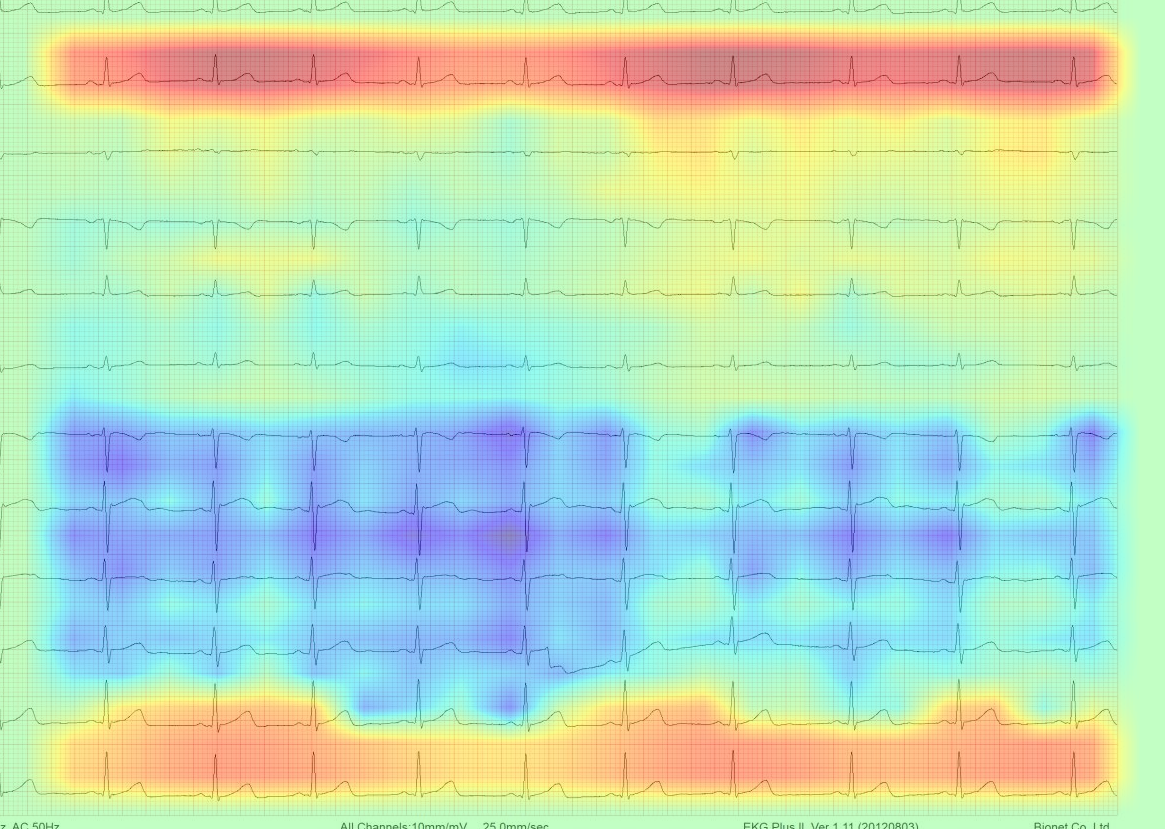

In [7]:
import os
import pandas as pd
import torch


# 1. Load the same CSV
df = pd.read_csv(CFG.metadata_csv)


# 2. Recreate the exact split used during training
n = len(df)

shuffled = df.sample(
    frac=1.0,
    random_state=CFG.seed
)

n_train = int(n * CFG.train_frac)
n_val = int(n * CFG.val_frac)

train_df = shuffled.iloc[:n_train].copy()

val_df = shuffled.iloc[
    n_train:n_train + n_val
].copy()

test_df = shuffled.iloc[
    n_train + n_val:
].copy()

print(
    f"Split recreated: train={len(train_df)}, "
    f"val={len(val_df)}, test={len(test_df)}"
)


# 3. Calculate normalization statistics from training data only
train_numeric_means = (
    train_df[NUMERIC_COLS]
    .mean()
    .fillna(0)
)

train_numeric_stds = (
    train_df[NUMERIC_COLS]
    .std()
    .replace(0, 1)
    .fillna(1)
)

print("Train-only normalization statistics recreated.")


# 4. Load the already trained model
model = CardioVLM().to(CFG.device)

checkpoint_path = os.path.join(
    CFG.out_dir,
    "cardiovlm_best.pt"
)

state_dict = torch.load(
    checkpoint_path,
    map_location=CFG.device
)

model.load_state_dict(state_dict)
model.eval()

print("Best model loaded successfully.")


# 5. Explain the first genuine test-set sample
test_row = test_df.iloc[0]

explain_prediction(
    model,
    test_row,
    CFG.device,
    train_numeric_means,
    train_numeric_stds
)

In [8]:
"""
Report generation quality evaluation
=====================================
Up to now the decoder's report output has only been eyeballed on single
samples ("Findings: Normal Axis." vs ground truth "Findings: Normal Sinus
Rhythm; Normal Axis; Normal ECG.") — this runs it systematically over the
whole TEST set (touched once, same set used for the final classification
numbers) and reports three things text quality metrics alone can't:

  1. Standard text-overlap metrics (BLEU-1/2, ROUGE-L) — how close the
     generated text is to the ground truth report, word-for-word.
  2. Condition-mention recall/precision — did the generated TEXT actually
     name the right conditions, regardless of exact wording? (a report that
     says "Findings: Sinus Bradycardia present" vs ground truth "Findings:
     Sinus Bradycardia" scores low on BLEU but should score perfectly here)
  3. Cross-head consistency — does the decoder's generated text agree with
     the classification head's own predictions on the SAME input? If the
     two heads disagree often, that's a real problem: it means the model
     doesn't have one coherent internal understanding of the ECG, it has two
     separate outputs that happen to share an encoder.

Run this in a new cell AFTER the main training cell (reuses CFG, CardioVLM,
CONDITION_VOCAB, PairedECGDataset, tokenizer, etc. already in the notebook).
"""

import json
import re
from collections import Counter


def extract_conditions_from_text(text, condition_vocab):
    """Same word-boundary matching parse_diagnosis uses on OCR'd text (fixes
    the earlier 'MI' substring-inside-'Minimally' bug) — applied here to the
    model's own generated/ground-truth report text instead of OCR output."""
    text_lower = text.lower()
    found = set()
    for cond in condition_vocab:
        if re.search(r"\b" + re.escape(cond.lower()) + r"\b", text_lower):
            found.add(cond)
    return found


def _ngrams(tokens, n):
    return Counter(tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1))


def bleu_n(candidate, reference, n):
    """Simple single-reference BLEU-n with add-1 smoothing (add-1 avoids the
    0-if-any-n-gram-is-missing cliff that plain BLEU has on short clinical
    sentences, where a single wrong word would otherwise zero out the score)."""
    cand_tokens = candidate.lower().split()
    ref_tokens = reference.lower().split()
    if len(cand_tokens) < n:
        return 0.0
    cand_ngrams = _ngrams(cand_tokens, n)
    ref_ngrams = _ngrams(ref_tokens, n)
    overlap = sum(min(c, ref_ngrams[g]) for g, c in cand_ngrams.items())
    total = sum(cand_ngrams.values())
    precision = (overlap + 1) / (total + 1)
    bp = 1.0 if len(cand_tokens) >= len(ref_tokens) else \
        np.exp(1 - len(ref_tokens) / max(len(cand_tokens), 1))
    return bp * precision


def rouge_l(candidate, reference):
    """ROUGE-L: F-measure over the longest common subsequence of tokens —
    rewards preserving the right words in the right relative order even if
    phrasing differs, which matters more for clinical text than exact n-gram
    match."""
    cand_tokens = candidate.lower().split()
    ref_tokens = reference.lower().split()
    if not cand_tokens or not ref_tokens:
        return 0.0
    m, n = len(cand_tokens), len(ref_tokens)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if cand_tokens[i - 1] == ref_tokens[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
    lcs = dp[m][n]
    if lcs == 0:
        return 0.0
    precision = lcs / m
    recall = lcs / n
    return 2 * precision * recall / (precision + recall)


def evaluate_report_quality(model, test_ds, device, condition_vocab, thresholds,
                              max_samples=None):
    model.eval()
    n = len(test_ds) if max_samples is None else min(max_samples, len(test_ds))

    bleu1_scores, bleu2_scores, rougeL_scores = [], [], []
    gen_vs_gt_tp = gen_vs_gt_fp = gen_vs_gt_fn = 0
    gen_vs_cls_agree = gen_vs_cls_total = 0
    examples = []

    with torch.no_grad():
        for i in range(n):
            sample = test_ds[i]
            ecg = sample["ecg_image"].unsqueeze(0).to(device)
            beat = sample["beat_image"].unsqueeze(0).to(device)
            numeric = sample["numeric"].unsqueeze(0).to(device)

            texts, _ = model.generate_report(ecg, beat, numeric)
            generated = texts[0]
            ground_truth = sample["report_text"]

            bleu1_scores.append(bleu_n(generated, ground_truth, 1))
            bleu2_scores.append(bleu_n(generated, ground_truth, 2))
            rougeL_scores.append(rouge_l(generated, ground_truth))

            gen_conds = extract_conditions_from_text(generated, condition_vocab)
            gt_conds = extract_conditions_from_text(ground_truth, condition_vocab)
            gen_vs_gt_tp += len(gen_conds & gt_conds)
            gen_vs_gt_fp += len(gen_conds - gt_conds)
            gen_vs_gt_fn += len(gt_conds - gen_conds)

            out = model(ecg, beat, numeric)
            probs = torch.sigmoid(out["logits"])[0].cpu().numpy()
            cls_conds = {name for name, p in zip(condition_vocab, probs) if p > thresholds[name]}
            gen_vs_cls_agree += len(gen_conds & cls_conds) + len((set(condition_vocab) - gen_conds) - cls_conds)
            gen_vs_cls_total += len(condition_vocab)

            if i < 10:
                examples.append((generated, ground_truth, gen_conds, gt_conds, cls_conds))

    precision = gen_vs_gt_tp / (gen_vs_gt_tp + gen_vs_gt_fp) if (gen_vs_gt_tp + gen_vs_gt_fp) > 0 else 0.0
    recall = gen_vs_gt_tp / (gen_vs_gt_tp + gen_vs_gt_fn) if (gen_vs_gt_tp + gen_vs_gt_fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    cross_head_agreement = gen_vs_cls_agree / gen_vs_cls_total if gen_vs_cls_total > 0 else 0.0

    print(f"\n=== Report generation quality (TEST set, n={n}) ===")
    print(f"BLEU-1:  {np.mean(bleu1_scores):.3f}")
    print(f"BLEU-2:  {np.mean(bleu2_scores):.3f}")
    print(f"ROUGE-L: {np.mean(rougeL_scores):.3f}")
    print(f"\nCondition-mention (generated text vs ground-truth text, word-boundary matched):")
    print(f"  precision={precision:.3f}  recall={recall:.3f}  F1={f1:.3f}")
    print(f"\nCross-head agreement (generated text's conditions vs classification "
          f"head's own predictions, same input, per-condition agreement rate):")
    print(f"  {cross_head_agreement:.3f}")
    if cross_head_agreement < 0.85:
        print("  -> Below 0.85: the decoder and classifier disagree often enough that "
              "they don't appear to share one coherent understanding of the ECG. Worth "
              "flagging as a limitation — the two output heads may be learning "
              "somewhat independent shortcuts rather than a unified representation.")

    print(f"\n=== {min(10, n)} example generations ===")
    for gen, gt, gen_c, gt_c, cls_c in examples:
        print(f"  Generated: {gen}")
        print(f"  Ground truth: {gt}")
        print(f"  Text-conditions: {sorted(gen_c)} | Ground-truth-conditions: {sorted(gt_c)} "
              f"| Classifier-conditions: {sorted(cls_c)}")
        print()

    return {
        "bleu1": float(np.mean(bleu1_scores)),
        "bleu2": float(np.mean(bleu2_scores)),
        "rougeL": float(np.mean(rougeL_scores)),
        "condition_precision": precision,
        "condition_recall": recall,
        "condition_f1": f1,
        "cross_head_agreement": cross_head_agreement,
    }


# ---------------------------------------------------------------------------
# Example usage (run in a new cell after the main training cell):
#
#   model = CardioVLM().to(CFG.device)
#   model.load_state_dict(torch.load(f"{CFG.out_dir}/cardiovlm_best.pt"))
#   with open(f"{CFG.out_dir}/label_config.json") as f:
#       label_config = json.load(f)
#   thresholds = label_config["thresholds"]
#
#   with open(f"{CFG.out_dir}/splits.json") as f:
#       splits = json.load(f)
#   df = pd.read_csv(CFG.metadata_csv, dtype={"patient_id": str})   # dtype forced —
#   # otherwise pandas silently infers patient_id as int64 on reload (it's an
#   # all-digit string column), which won't match the strings saved in
#   # splits.json and test_df comes back empty (n=0) with no error
#   test_df = df[df["patient_id"].isin(splits["test"])]
#   tokenizer = AutoTokenizer.from_pretrained(CFG.decoder_name)
#   test_ds = PairedECGDataset(test_df, tokenizer)
#
#   results = evaluate_report_quality(model, test_ds, CFG.device, CONDITION_VOCAB, thresholds)
#
# Uses the SAME test set as the final classification numbers (via splits.json)
# so this is a genuinely held-out check, not re-using train/val data.
# ---------------------------------------------------------------------------

In [9]:
# Report generation quality evaluation -- standalone, fast.
# Only needs artifacts already saved on disk from your earlier full run:
#   cardiovlm_best.pt, splits.json, label_config.json
# Does NOT require re-running training, the 5-fold CV, or the multi-seed
# cells in this session.

model = CardioVLM().to(CFG.device)
model.load_state_dict(torch.load(f"{CFG.out_dir}/cardiovlm_best.pt", map_location=CFG.device))
model.eval()

with open(f"{CFG.out_dir}/label_config.json") as f:
    label_config = json.load(f)
thresholds = label_config["thresholds"]

with open(f"{CFG.out_dir}/splits.json") as f:
    splits = json.load(f)

df = pd.read_csv(CFG.metadata_csv, dtype={"patient_id": str})   # dtype forced --
# otherwise pandas silently infers patient_id as int64 on reload (it's an
# all-digit string column), which won't match the strings saved in
# splits.json and test_df comes back empty (n=0) with no error
train_df = df[df["patient_id"].isin(splits["train"])]
test_df = df[df["patient_id"].isin(splits["test"])]

# Recompute the SAME train-only normalization stats main() originally used.
# This is deterministic from splits.json + the CSV (cheap pandas ops, no
# training), so it does not depend on the CV or multi-seed cells having run
# this session -- fixes the earlier silent dependency on cell 6's globals.
train_numeric_means = train_df[NUMERIC_COLS].mean().fillna(0)
train_numeric_stds = train_df[NUMERIC_COLS].std().replace(0, 1).fillna(1)

tokenizer = AutoTokenizer.from_pretrained(CFG.decoder_name)
test_ds = PairedECGDataset(
    test_df,
    tokenizer,
    train=False,
    numeric_means=train_numeric_means,
    numeric_stds=train_numeric_stds
)

results = evaluate_report_quality(model, test_ds, CFG.device, CONDITION_VOCAB, thresholds)


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning



=== Report generation quality (TEST set, n=375) ===
BLEU-1:  0.752
BLEU-2:  0.726
ROUGE-L: 0.801

Condition-mention (generated text vs ground-truth text, word-boundary matched):
  precision=0.881  recall=0.728  F1=0.797

Cross-head agreement (generated text's conditions vs classification head's own predictions, same input, per-condition agreement rate):
  0.938

=== 10 example generations ===
  Generated: Findings: Normal Sinus Rhythm; Normal Axis; Normal ECG.
  Ground truth: Findings: Normal Sinus Rhythm; Normal Axis; Normal ECG.
  Text-conditions: ['Normal Axis', 'Normal ECG', 'Normal Sinus Rhythm'] | Ground-truth-conditions: ['Normal Axis', 'Normal ECG', 'Normal Sinus Rhythm'] | Classifier-conditions: ['Normal Axis', 'Normal ECG', 'Normal Sinus Rhythm']

  Generated: Findings: Normal Axis; Sinus Bradycardia.
  Ground truth: Findings: Normal Axis; Sinus Bradycardia.
  Text-conditions: ['Normal Axis', 'Sinus Bradycardia'] | Ground-truth-conditions: ['Normal Axis', 'Sinus Bradycardia'